
FULL RISK REGISTER
   Risk_ID                                   Risk_Description  \
0       R1  Competitive pressure from digital-first insure...   
1       R2  Customer service and retention weaken due to d...   
2       R3  Strategic delay in digital product rollout wea...   
3       R4  Smaller control failures create inefficiencies...   
4       R5  Major strategic disruption from aggressive fin...   
5       R6  High reputational and financial damage from ma...   
6       R7  Low-level process interruptions reduce workflo...   
7       R8  Emerging competitors increase pressure in sele...   
8       R9  Minor system-control weaknesses affect process...   
9      R10  Moderate operational disruption due to integra...   
10     R11  Cybersecurity weaknesses affect customer trust...   
11     R12  Severe compliance or market risk creates major...   
12     R13  Limited internal process gaps reduce operating...   
13     R14  Technology adaptation issues create moderate p...   
14   

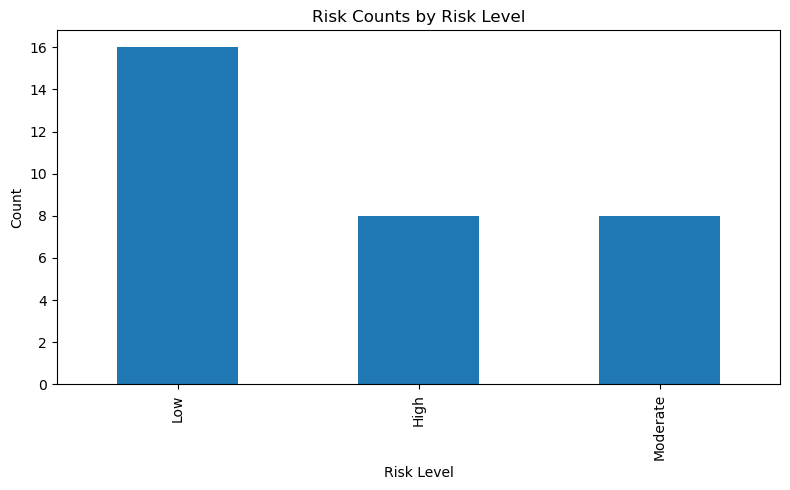

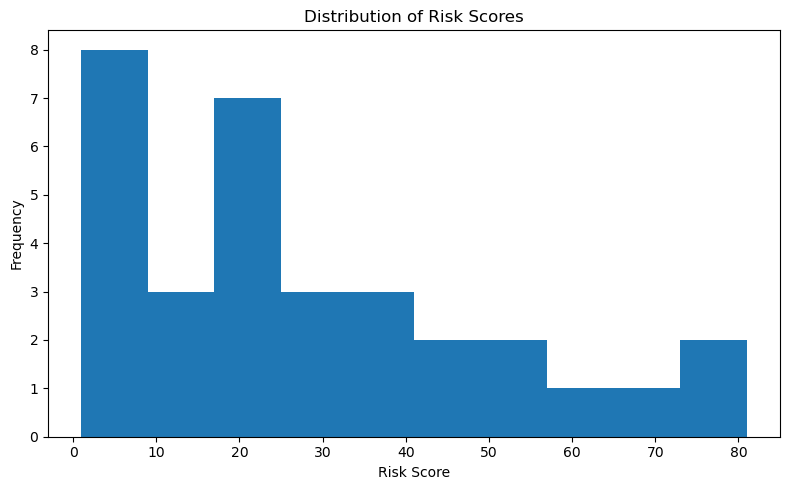

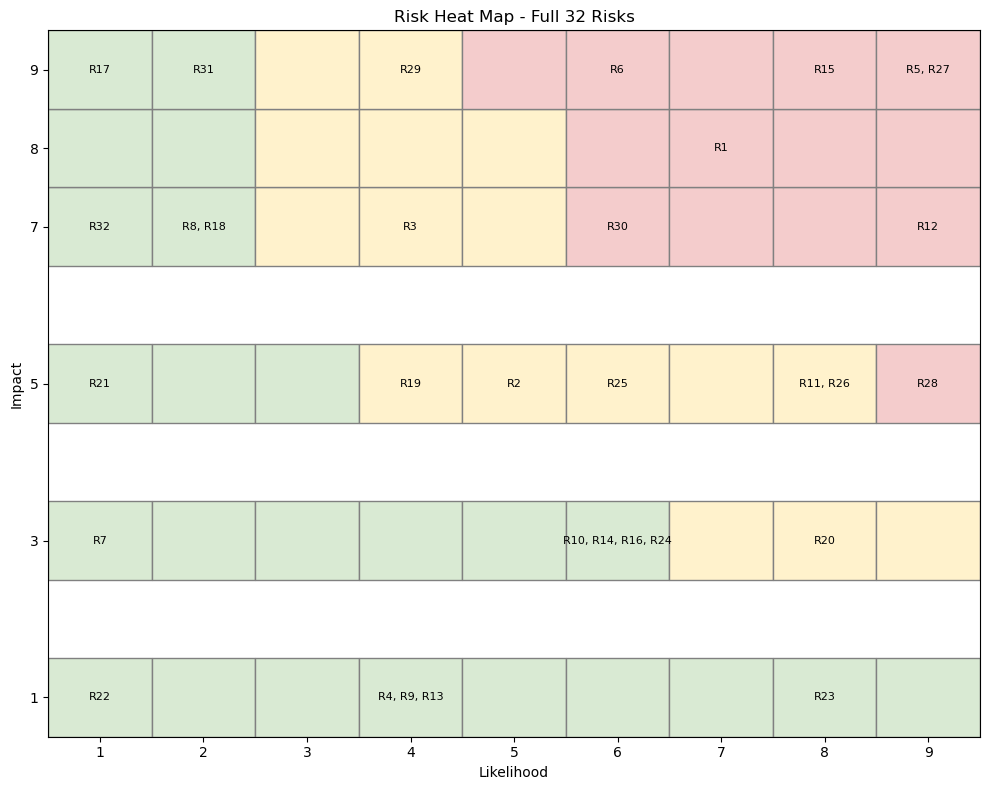


TOP RISKS BY EXPECTED LOSS
   Risk_ID                 Category  Probability  Financial_Impact_M  \
26     R27               Enterprise          0.9          130.000000   
14     R15     Regulatory/Strategic          0.8           95.000000   
4       R5                Strategic          0.9           80.000000   
11     R12     Compliance/Strategic          0.9           70.000000   
0       R1                Strategic          0.7           71.111111   
5       R6               Technology          0.6           70.000000   
27     R28                Strategic          0.9           44.444444   
28     R29  Regulatory/Reputational          0.4           85.000000   
25     R26     Strategic/Technology          0.8           41.666667   
29     R30    Strategic/Operational          0.6           54.444444   

    Expected_Loss_M  Variance_M2  
26       117.000000  1521.000000  
14        76.000000  1444.000000  
4         72.000000   576.000000  
11        63.000000   441.000000  
0   

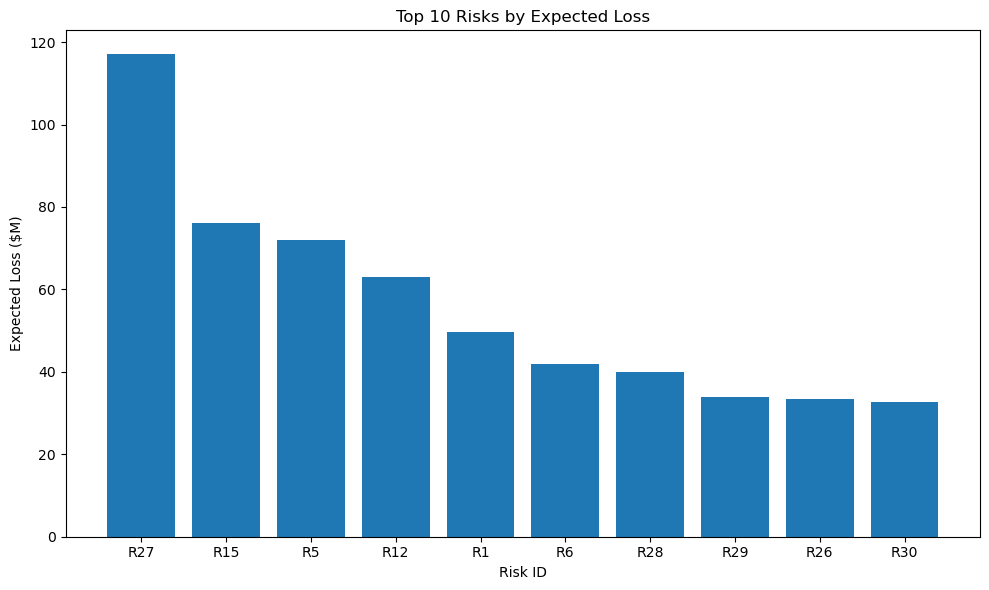


SCENARIO ANALYSIS
  Scenario  Portfolio_Expected_Loss_M  High_Risk_Expected_Loss_M
0     Base                 752.166667                 492.444444
1   Stress                1024.363333                 665.946667
2   Severe                1281.272222                 813.711111


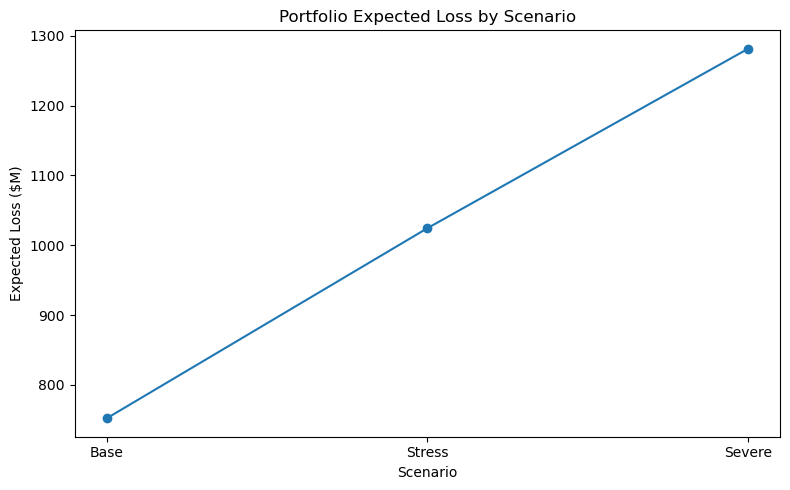


ML MODEL RESULTS
Accuracy: 0.75
Precision: 0.691
Recall: 0.618
ROC-AUC: 0.823

Confusion Matrix:
 [[103  21]
 [ 29  47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80       124
           1       0.69      0.62      0.65        76

    accuracy                           0.75       200
   macro avg       0.74      0.72      0.73       200
weighted avg       0.75      0.75      0.75       200


TOP RISKS BY PREDICTED ESCALATION PROBABILITY
   Risk_ID                                   Risk_Description  \
14     R15  High-impact regulatory or strategic failure ha...   
4       R5  Major strategic disruption from aggressive fin...   
11     R12  Severe compliance or market risk creates major...   
0       R1  Competitive pressure from digital-first insure...   
5       R6  High reputational and financial damage from ma...   
26     R27  Critical enterprise-wide disruption creates se...   
25     R26  Competitive 

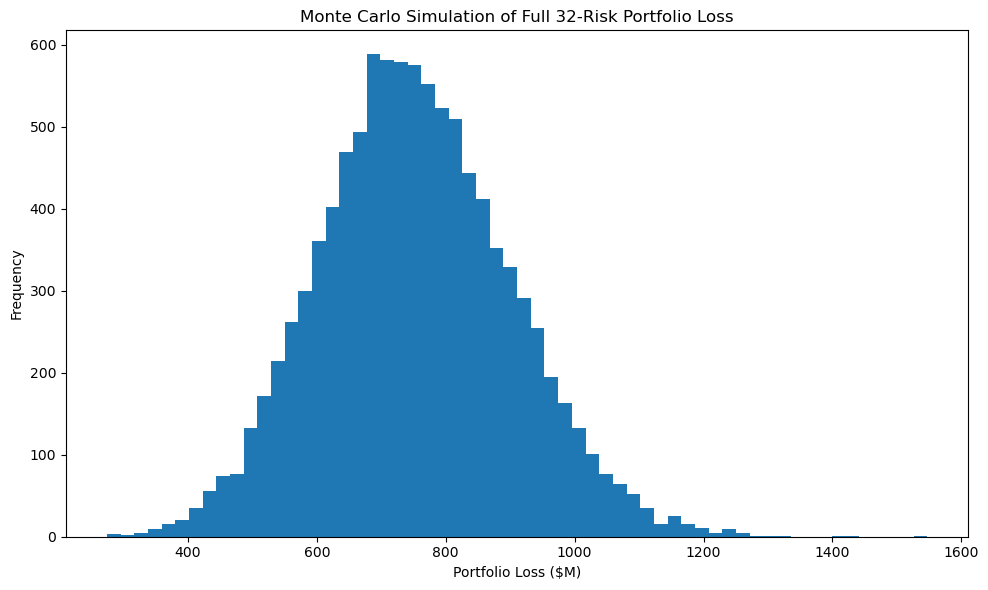


FINAL PRIORITIZED REGISTER
   Risk_ID                                   Risk_Description  \
26     R27  Critical enterprise-wide disruption creates se...   
14     R15  High-impact regulatory or strategic failure ha...   
4       R5  Major strategic disruption from aggressive fin...   
11     R12  Severe compliance or market risk creates major...   
0       R1  Competitive pressure from digital-first insure...   
5       R6  High reputational and financial damage from ma...   
25     R26  Competitive and technology risks affect market...   
27     R28  High-likelihood risk causes meaningful strateg...   
29     R30  Strategic and operational pressure increases c...   
28     R29  Regulatory or reputational event creates serio...   
10     R11  Cybersecurity weaknesses affect customer trust...   
2       R3  Strategic delay in digital product rollout wea...   
30     R31  Low-likelihood but high-impact risk remains im...   
24     R25  Process or system weakness causes moderate ser... 

In [2]:
# ============================================================
# ENTERPRISE RISK MANAGEMENT ANALYTICS - FINAL PROJECT
# Manulife Financial: Full 32-Risk Assessment
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ============================================================
# 1. FULL 32-RISK DATASET
# ============================================================
risks = [
    ("R1",  "Competitive pressure from digital-first insurers reduces market share", "Strategic", 7, 8),
    ("R2",  "Customer service and retention weaken due to digital experience gaps", "Operational", 5, 5),
    ("R3",  "Strategic delay in digital product rollout weakens competitiveness", "Strategic", 4, 7),
    ("R4",  "Smaller control failures create inefficiencies in internal operations", "Operational", 4, 1),
    ("R5",  "Major strategic disruption from aggressive fintech and insurtech competition", "Strategic", 9, 9),
    ("R6",  "High reputational and financial damage from major technology failure", "Technology", 6, 9),
    ("R7",  "Low-level process interruptions reduce workflow efficiency", "Operational", 1, 3),
    ("R8",  "Emerging competitors increase pressure in selected product lines", "Strategic", 2, 7),
    ("R9",  "Minor system-control weaknesses affect process consistency", "Operational", 4, 1),
    ("R10", "Moderate operational disruption due to integration challenges", "Operational", 6, 3),
    ("R11", "Cybersecurity weaknesses affect customer trust and operations", "Technology", 8, 5),
    ("R12", "Severe compliance or market risk creates major strategic exposure", "Compliance/Strategic", 9, 7),
    ("R13", "Limited internal process gaps reduce operating efficiency", "Operational", 4, 1),
    ("R14", "Technology adaptation issues create moderate process inefficiencies", "Technology", 6, 3),
    ("R15", "High-impact regulatory or strategic failure harms business performance", "Regulatory/Strategic", 8, 9),
    ("R16", "Operational reliability concerns create recurring process issues", "Operational", 6, 3),
    ("R17", "Small but frequent low-cost risk events require monitoring", "Operational", 1, 9),
    ("R18", "Competitor expansion affects long-term strategic positioning", "Strategic", 2, 7),
    ("R19", "Moderate strategic execution risk affects digital competitiveness", "Strategic", 4, 5),
    ("R20", "Moderate business process risk affects service continuity", "Operational", 8, 3),
    ("R21", "Isolated low-severity risks affect a small business segment", "Operational", 1, 5),
    ("R22", "Minimal low-impact operational issues occur at routine level", "Operational", 1, 1),
    ("R23", "Low-frequency business interruptions create limited operational effect", "Operational", 8, 1),
    ("R24", "Repeated operational friction affects cost efficiency", "Operational", 6, 3),
    ("R25", "Process or system weakness causes moderate service disruption", "Operational", 6, 5),
    ("R26", "Competitive and technology risks affect market confidence", "Strategic/Technology", 8, 5),
    ("R27", "Critical enterprise-wide disruption creates severe financial risk", "Enterprise", 9, 9),
    ("R28", "High-likelihood risk causes meaningful strategic and service impact", "Strategic", 9, 5),
    ("R29", "Regulatory or reputational event creates serious business exposure", "Regulatory/Reputational", 4, 9),
    ("R30", "Strategic and operational pressure increases competitive vulnerability", "Strategic/Operational", 6, 7),
    ("R31", "Low-likelihood but high-impact risk remains important to monitor", "Enterprise", 2, 9),
    ("R32", "Moderate competitive threat affects growth potential", "Strategic", 1, 7),
]

df = pd.DataFrame(
    risks,
    columns=["Risk_ID", "Risk_Description", "Category", "Likelihood", "Impact"]
)

df["Score"] = df["Likelihood"] * df["Impact"]

def classify_level(score):
    if score <= 18:
        return "Low"
    elif score <= 40:
        return "Moderate"
    return "High"

df["Risk_Level"] = df["Score"].apply(classify_level)

print("\nFULL RISK REGISTER")
print(df)

# ============================================================
# 2. EDA / DESCRIPTIVE ANALYSIS
# ============================================================
print("\nRISK LEVEL COUNTS")
print(df["Risk_Level"].value_counts())

print("\nCATEGORY COUNTS")
print(df["Category"].value_counts())

print("\nAVERAGE SCORE BY CATEGORY")
print(df.groupby("Category")["Score"].mean().sort_values(ascending=False))

print("\nSUMMARY STATISTICS")
print(df[["Likelihood", "Impact", "Score"]].describe())

# Bar chart: Risk counts by level
plt.figure(figsize=(8, 5))
df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Counts by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Histogram of risk scores
plt.figure(figsize=(8, 5))
plt.hist(df["Score"], bins=10)
plt.title("Distribution of Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 3. HEAT MAP
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

impact_values = sorted(df["Impact"].unique())
for x in range(1, 10):
    for y in impact_values:
        score = x * y
        if score <= 18:
            color = "#d9ead3"  # green
        elif score <= 40:
            color = "#fff2cc"  # yellow
        else:
            color = "#f4cccc"  # red
        ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor=color, edgecolor="gray"))

grouped = df.groupby(["Likelihood", "Impact"])["Risk_ID"].apply(lambda x: ", ".join(x)).reset_index()

for _, row in grouped.iterrows():
    ax.text(row["Likelihood"], row["Impact"], row["Risk_ID"], ha="center", va="center", fontsize=8)

ax.set_xticks(range(1, 10))
ax.set_yticks(impact_values)
ax.set_xlabel("Likelihood")
ax.set_ylabel("Impact")
ax.set_title("Risk Heat Map - Full 32 Risks")
ax.set_xlim(0.5, 9.5)
ax.set_ylim(min(impact_values) - 0.5, max(impact_values) + 0.5)
plt.tight_layout()
plt.show()

# ============================================================
# 4. STANDARDIZED QUANTITATIVE MODELING
# ============================================================
# Convert likelihood into probability
df["Probability"] = df["Likelihood"] / 10.0

# Proxy financial impact assumptions by category (millions)
impact_map = {
    "Operational": 25,
    "Technology": 70,
    "Strategic": 80,
    "Compliance/Strategic": 90,
    "Regulatory/Strategic": 95,
    "Strategic/Technology": 75,
    "Enterprise": 130,
    "Regulatory/Reputational": 85,
    "Strategic/Operational": 70
}

df["Base_Impact_M"] = df["Category"].map(impact_map)
df["Financial_Impact_M"] = df["Base_Impact_M"] * (df["Impact"] / 9.0)

# Expected loss
df["Expected_Loss_M"] = df["Probability"] * df["Financial_Impact_M"]

# Variance approximation
df["Variance_M2"] = df["Probability"] * (1 - df["Probability"]) * (df["Financial_Impact_M"] ** 2)

print("\nTOP RISKS BY EXPECTED LOSS")
top_expected = df.sort_values("Expected_Loss_M", ascending=False)[
    ["Risk_ID", "Category", "Probability", "Financial_Impact_M", "Expected_Loss_M", "Variance_M2"]
]
print(top_expected.head(10))

# Chart: Top 10 by expected loss
top10 = top_expected.head(10)
plt.figure(figsize=(10, 6))
plt.bar(top10["Risk_ID"], top10["Expected_Loss_M"])
plt.title("Top 10 Risks by Expected Loss")
plt.xlabel("Risk ID")
plt.ylabel("Expected Loss ($M)")
plt.tight_layout()
plt.show()

# ============================================================
# 5. SCENARIO ANALYSIS
# ============================================================
scenarios = {
    "Base": {"prob_mult": 1.00, "impact_mult": 1.00},
    "Stress": {"prob_mult": 1.15, "impact_mult": 1.20},
    "Severe": {"prob_mult": 1.30, "impact_mult": 1.40},
}

scenario_results = []

for name, params in scenarios.items():
    temp = df.copy()
    temp["Scenario_Prob"] = np.clip(temp["Probability"] * params["prob_mult"], 0, 1)
    temp["Scenario_Impact_M"] = temp["Financial_Impact_M"] * params["impact_mult"]
    temp["Scenario_Expected_Loss_M"] = temp["Scenario_Prob"] * temp["Scenario_Impact_M"]

    scenario_results.append({
        "Scenario": name,
        "Portfolio_Expected_Loss_M": temp["Scenario_Expected_Loss_M"].sum(),
        "High_Risk_Expected_Loss_M": temp.loc[temp["Risk_Level"] == "High", "Scenario_Expected_Loss_M"].sum()
    })

scenario_df = pd.DataFrame(scenario_results)

print("\nSCENARIO ANALYSIS")
print(scenario_df)

plt.figure(figsize=(8, 5))
plt.plot(scenario_df["Scenario"], scenario_df["Portfolio_Expected_Loss_M"], marker="o")
plt.title("Portfolio Expected Loss by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Expected Loss ($M)")
plt.tight_layout()
plt.show()

# ============================================================
# 6. SYNTHETIC KRI DATA FOR MACHINE LEARNING
# ============================================================
rng = np.random.default_rng(42)
n_obs = 800

sampled = df.sample(n=n_obs, replace=True, random_state=42).reset_index(drop=True)

sampled["market_pressure"] = np.where(
    sampled["Category"].str.contains("Strategic"),
    rng.normal(0.60, 0.15, n_obs),
    rng.normal(0.30, 0.10, n_obs)
)

sampled["churn_rate"] = np.where(
    sampled["Category"].str.contains("Strategic|Operational"),
    rng.normal(0.18, 0.05, n_obs),
    rng.normal(0.10, 0.03, n_obs)
)

sampled["vulnerability_rate"] = np.where(
    sampled["Category"].str.contains("Technology"),
    rng.normal(0.22, 0.07, n_obs),
    rng.normal(0.08, 0.03, n_obs)
)

sampled["downtime_hours"] = np.where(
    sampled["Category"].str.contains("Technology|Operational"),
    rng.normal(4.0, 1.5, n_obs),
    rng.normal(1.5, 0.8, n_obs)
)

sampled["regulatory_pressure"] = np.where(
    sampled["Category"].str.contains("Compliance|Regulatory"),
    rng.normal(0.25, 0.08, n_obs),
    rng.normal(0.10, 0.04, n_obs)
)

sampled["digital_penetration"] = np.where(
    sampled["Category"].str.contains("Strategic"),
    rng.normal(0.55, 0.15, n_obs),
    rng.normal(0.35, 0.10, n_obs)
)

# Remove negatives if any
for col in [
    "market_pressure", "churn_rate", "vulnerability_rate",
    "downtime_hours", "regulatory_pressure", "digital_penetration"
]:
    sampled[col] = sampled[col].clip(lower=0)

# Synthetic target: whether the risk escalates to high
logit_score = (
    0.35 * sampled["Likelihood"] +
    0.40 * sampled["Impact"] +
    2.0 * sampled["market_pressure"] +
    2.2 * sampled["vulnerability_rate"] +
    0.15 * sampled["downtime_hours"] +
    1.8 * sampled["regulatory_pressure"] -
    1.5 * sampled["digital_penetration"]
)

prob_escalate = 1 / (1 + np.exp(-(logit_score - 5.8)))
sampled["Risk_Escalates"] = rng.binomial(1, np.clip(prob_escalate, 0, 1))

# ============================================================
# 7. MACHINE LEARNING MODEL
# ============================================================
features = [
    "Category", "Likelihood", "Impact", "market_pressure", "churn_rate",
    "vulnerability_rate", "downtime_hours", "regulatory_pressure", "digital_penetration"
]
target = "Risk_Escalates"

X = sampled[features]
y = sampled[target]

categorical = ["Category"]
numeric = [c for c in features if c not in categorical]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric)
    ]
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("\nML MODEL RESULTS")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Predicted escalation probability for the original 32 risks
risk_pred = df.copy()
risk_pred["market_pressure"] = np.where(risk_pred["Category"].str.contains("Strategic"), 0.60, 0.30)
risk_pred["churn_rate"] = np.where(risk_pred["Category"].str.contains("Strategic|Operational"), 0.18, 0.10)
risk_pred["vulnerability_rate"] = np.where(risk_pred["Category"].str.contains("Technology"), 0.22, 0.08)
risk_pred["downtime_hours"] = np.where(risk_pred["Category"].str.contains("Technology|Operational"), 4.0, 1.5)
risk_pred["regulatory_pressure"] = np.where(risk_pred["Category"].str.contains("Compliance|Regulatory"), 0.25, 0.10)
risk_pred["digital_penetration"] = np.where(risk_pred["Category"].str.contains("Strategic"), 0.55, 0.35)

risk_pred["Predicted_Escalation_Prob"] = clf.predict_proba(risk_pred[features])[:, 1]

print("\nTOP RISKS BY PREDICTED ESCALATION PROBABILITY")
print(
    risk_pred[["Risk_ID", "Risk_Description", "Predicted_Escalation_Prob"]]
    .sort_values("Predicted_Escalation_Prob", ascending=False)
    .head(10)
)

# ============================================================
# 8. MONTE CARLO SIMULATION - FULL 32-RISK PORTFOLIO
# ============================================================
simulations = 10000
portfolio_losses = np.zeros(simulations)

volatility_map = {
    "Operational": 0.20,
    "Technology": 0.30,
    "Strategic": 0.28,
    "Compliance/Strategic": 0.32,
    "Regulatory/Strategic": 0.35,
    "Strategic/Technology": 0.30,
    "Enterprise": 0.40,
    "Regulatory/Reputational": 0.33,
    "Strategic/Operational": 0.27
}

for i in range(simulations):
    total_loss = 0.0
    for _, row in df.iterrows():
        p = row["Probability"]
        impact_mean = row["Financial_Impact_M"]
        vol = volatility_map[row["Category"]]
        occurs = np.random.rand() < p

        if occurs:
            sigma = vol
            mu = np.log(max(impact_mean, 1e-6)) - 0.5 * sigma**2
            loss = np.random.lognormal(mean=mu, sigma=sigma)
            total_loss += loss

    portfolio_losses[i] = total_loss

avg_loss = portfolio_losses.mean()
p95_loss = np.percentile(portfolio_losses, 95)
p99_loss = np.percentile(portfolio_losses, 99)
max_loss = portfolio_losses.max()

print("\nMONTE CARLO PORTFOLIO RESULTS")
print("Average Portfolio Loss ($M):", round(avg_loss, 2))
print("95th Percentile Loss ($M):", round(p95_loss, 2))
print("99th Percentile Loss ($M):", round(p99_loss, 2))
print("Maximum Simulated Loss ($M):", round(max_loss, 2))

plt.figure(figsize=(10, 6))
plt.hist(portfolio_losses, bins=60)
plt.title("Monte Carlo Simulation of Full 32-Risk Portfolio Loss")
plt.xlabel("Portfolio Loss ($M)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 9. FINAL PRIORITIZED REGISTER
# ============================================================
# FIXED VERSION: no merge needed, because risk_pred already came from df.copy()
final_priority = risk_pred.copy()

final_priority["Priority_Index"] = (
    0.5 * (final_priority["Expected_Loss_M"] / final_priority["Expected_Loss_M"].max()) +
    0.5 * final_priority["Predicted_Escalation_Prob"]
)

final_priority = final_priority.sort_values("Priority_Index", ascending=False)

print("\nFINAL PRIORITIZED REGISTER")
print(
    final_priority[[
        "Risk_ID",
        "Risk_Description",
        "Category",
        "Risk_Level",
        "Expected_Loss_M",
        "Predicted_Escalation_Prob",
        "Priority_Index"
    ]].head(15)
)

# ============================================================
# 10. SAVE OUTPUTS
# ============================================================
df.to_csv("full_32_risk_register.csv", index=False)
scenario_df.to_csv("scenario_analysis_summary.csv", index=False)
final_priority.to_csv("prioritized_risk_register_with_ml.csv", index=False)

print("\nSaved files:")
print("- full_32_risk_register.csv")
print("- scenario_analysis_summary.csv")
print("- prioritized_risk_register_with_ml.csv")